# Análise Exploratória — Dados Limpos

Este notebook parte dos dados já processados por `limpeza.ipynb`, carregados a partir do Parquet. Foco em insights finais antes da modelagem.

In [2]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from modules.data_loader import load_flights_clean, build_classification_split

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
df = load_flights_clean()
print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")

Shape: (5729195, 39)
Colunas: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'ORIGIN_CITY', 'ORIGIN_STATE', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_CITY', 'DEST_STATE', 'DEST_LAT', 'DEST_LON', 'DEP_HOUR', 'SEASON', 'IS_WEEKEND', 'IS_SHORT_DISTANCE', 'IS_LONG_DISTANCE', 'IS_MORNING', 'IS_AFTERNOON', 'IS_NIGHT', 'IS_HOLIDAY', 'IS_DELAYED']


## Distribuições das Features de Modelagem

Verificação das variáveis que serão usadas na modelagem supervisionada.

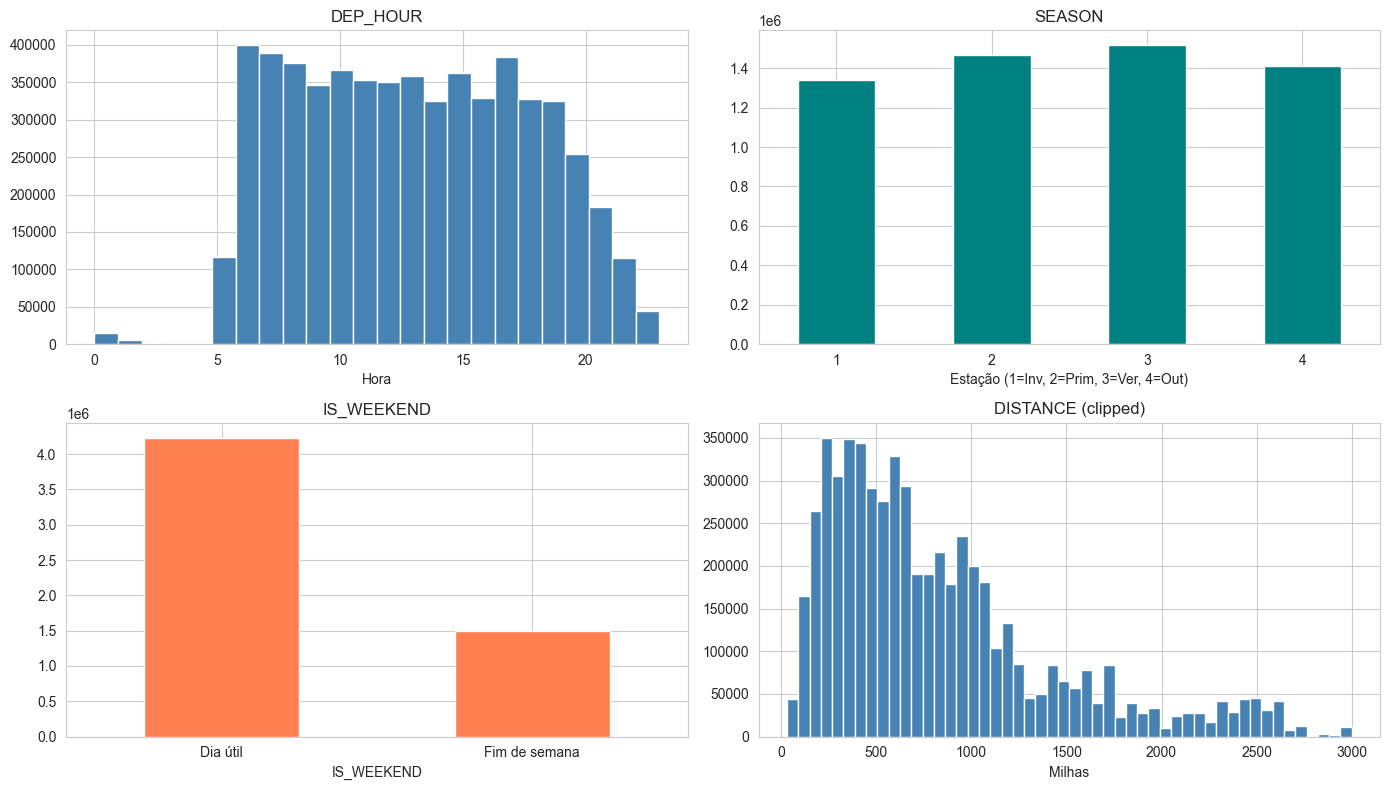

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df['DEP_HOUR'].hist(bins=24, ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('DEP_HOUR')
axes[0, 0].set_xlabel('Hora')

df['SEASON'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='teal', edgecolor='white')
axes[0, 1].set_title('SEASON')
axes[0, 1].set_xlabel('Estação (1=Inv, 2=Prim, 3=Ver, 4=Out)')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

df['IS_WEEKEND'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='coral', edgecolor='white')
axes[1, 0].set_title('IS_WEEKEND')
axes[1, 0].set_xticklabels(['Dia útil', 'Fim de semana'], rotation=0)

df['DISTANCE'].clip(0, 3000).hist(bins=50, ax=axes[1, 1], color='steelblue', edgecolor='white')
axes[1, 1].set_title('DISTANCE (clipped)')
axes[1, 1].set_xlabel('Milhas')

plt.tight_layout()
plt.show()

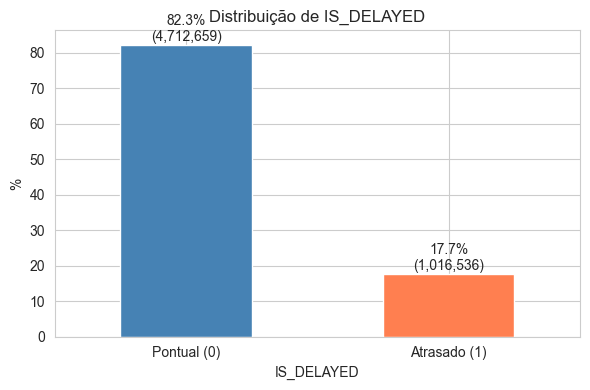

In [5]:
balance = df['IS_DELAYED'].value_counts(normalize=True) * 100
counts = df['IS_DELAYED'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
balance.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='white', ax=ax)
ax.set_title('Distribuição de IS_DELAYED')
ax.set_xticklabels(['Pontual (0)', 'Atrasado (1)'], rotation=0)
ax.set_ylabel('%')

for i, (pct, cnt) in enumerate(zip(balance, counts)):
    ax.text(i, pct + 1, f'{pct:.1f}%\n({cnt:,})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Correlações no Dataset Limpo

Matriz de correlação entre as variáveis numéricas relacionadas a atraso, após a limpeza (NaN imputados com 0, cancelados removidos).

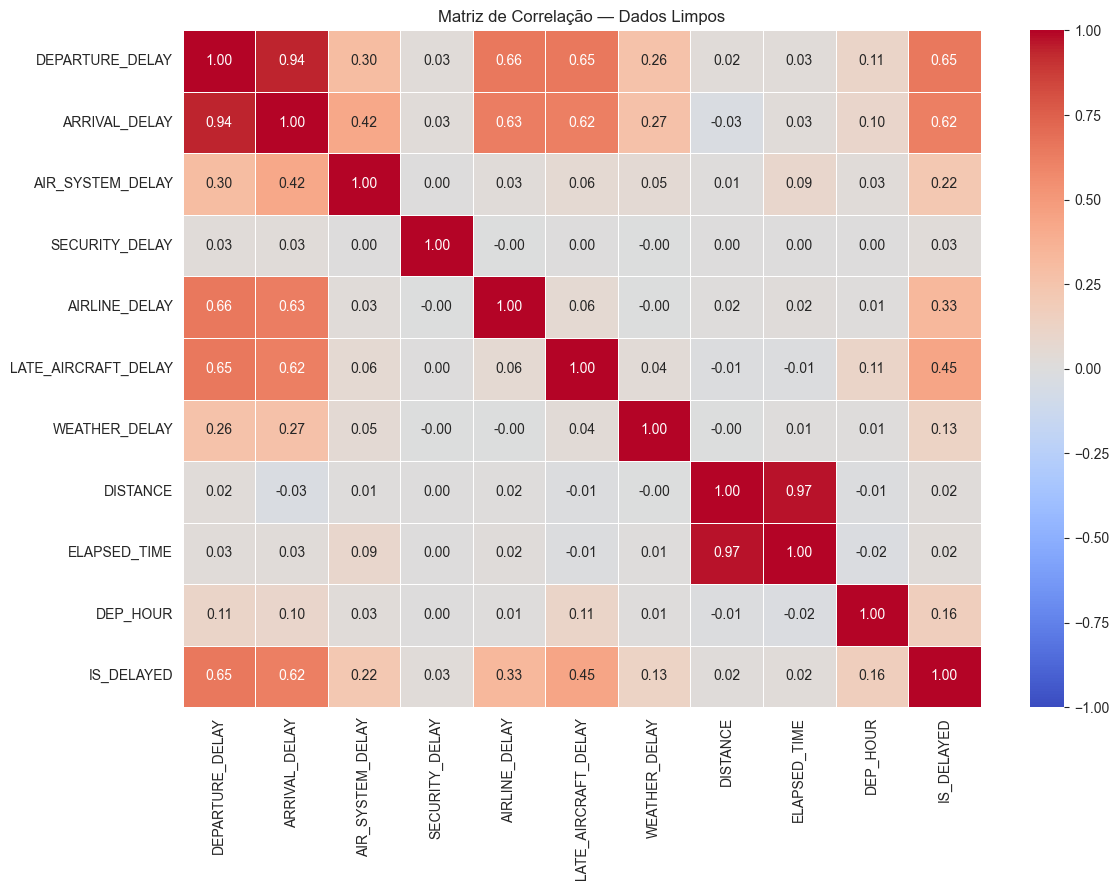

In [6]:
numeric_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
                'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
                'WEATHER_DELAY', 'DISTANCE', 'ELAPSED_TIME', 'DEP_HOUR',
                'IS_DELAYED']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação — Dados Limpos')
plt.tight_layout()
plt.show()

## Análise por Companhia Aérea

Comparação de atraso médio e taxa de atraso (>15 min) entre as 14 companhias, usando dados limpos (sem cancelados).

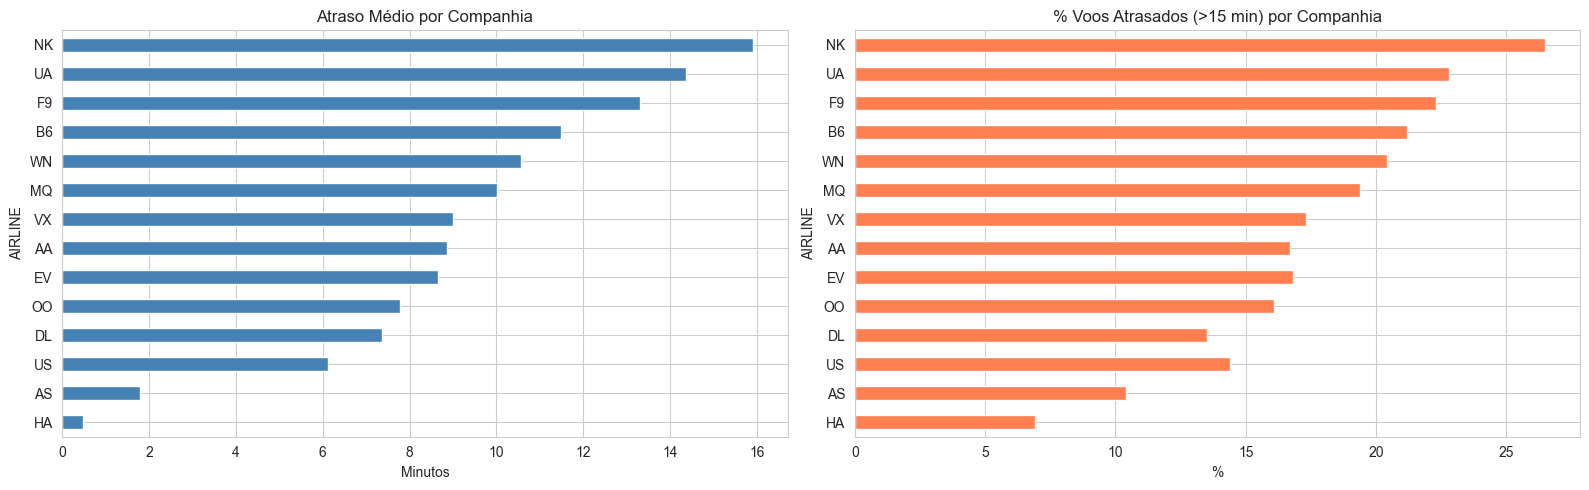

In [7]:
airline_stats = df.groupby('AIRLINE').agg(
    avg_delay=('DEPARTURE_DELAY', 'mean'),
    pct_delayed=('IS_DELAYED', 'mean'),
    total_flights=('IS_DELAYED', 'count')
).sort_values('avg_delay', ascending=False)
airline_stats['pct_delayed'] = (airline_stats['pct_delayed'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

airline_stats['avg_delay'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Atraso Médio por Companhia')
axes[0].set_xlabel('Minutos')
axes[0].invert_yaxis()

airline_stats['pct_delayed'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('% Voos Atrasados (>15 min) por Companhia')
axes[1].set_xlabel('%')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Padrões Temporais

Atraso por hora do dia, dia da semana e mês — nos dados limpos.

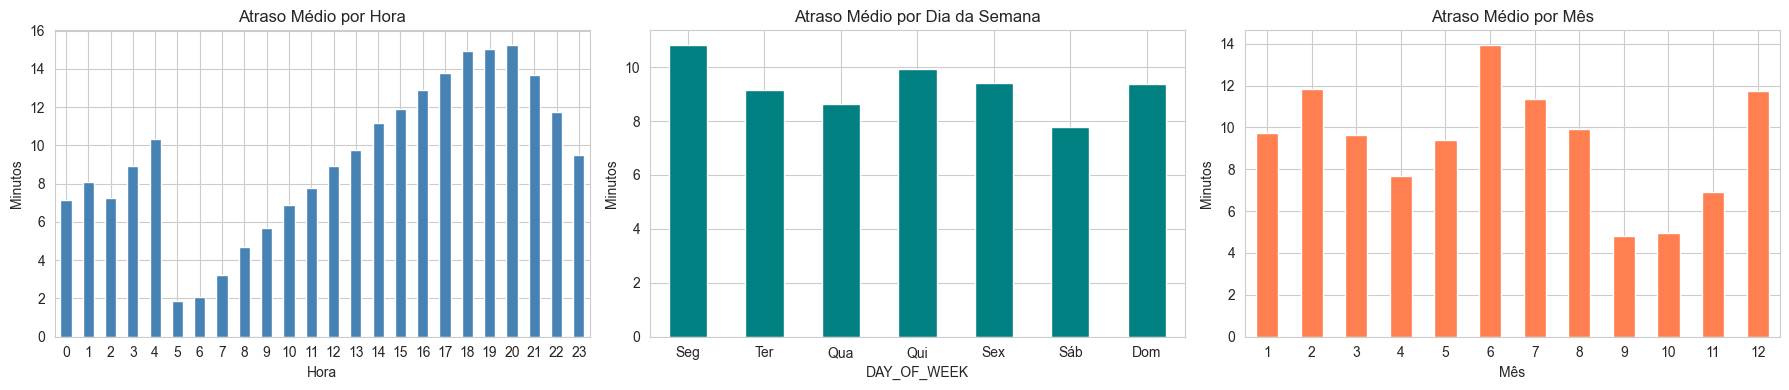

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Por hora
df.groupby('DEP_HOUR')['DEPARTURE_DELAY'].mean().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Atraso Médio por Hora')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Minutos')

# Por dia da semana
day_labels = {1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb', 7: 'Dom'}
dow = df.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
dow.index = dow.index.map(day_labels)
dow.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Atraso Médio por Dia da Semana')
axes[1].set_ylabel('Minutos')

# Por mês
df.groupby('MONTH')['DEPARTURE_DELAY'].mean().plot(kind='bar', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Atraso Médio por Mês')
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Minutos')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

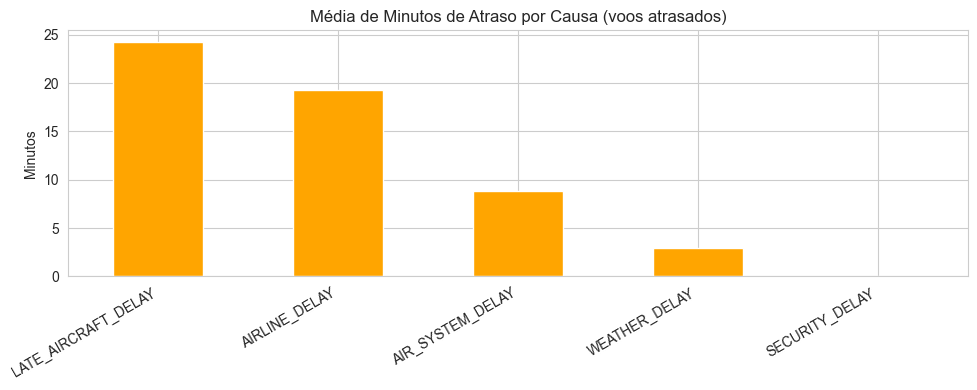

In [9]:
delay_cause_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delayed = df[df['IS_DELAYED'] == 1]
cause_means = delayed[delay_cause_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
cause_means.plot(kind='bar', color='orange', edgecolor='white')
plt.title('Média de Minutos de Atraso por Causa (voos atrasados)')
plt.ylabel('Minutos')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Feature Matrix

Construção da matriz de features para verificar shapes antes da modelagem. Utilizamos o módulo `data_loader` para garantir consistência.

In [10]:
X_train, X_test, y_train, y_test = build_classification_split(df)

print(f"Features: {list(X_train.columns)}")
print(f"\nTreino:  X={X_train.shape}, y={y_train.shape}")
print(f"Teste:   X={X_test.shape}, y={y_test.shape}")
print(f"\nBalance treino: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Balance teste:  {y_test.value_counts(normalize=True).to_dict()}")

Features: ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'SEASON', 'IS_WEEKEND', 'DISTANCE', 'IS_SHORT_DISTANCE', 'IS_LONG_DISTANCE', 'IS_MORNING', 'IS_AFTERNOON', 'IS_NIGHT', 'IS_HOLIDAY', 'AIRLINE_AA', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV', 'AIRLINE_F9', 'AIRLINE_HA', 'AIRLINE_MQ', 'AIRLINE_NK', 'AIRLINE_OO', 'AIRLINE_UA', 'AIRLINE_US', 'AIRLINE_VX', 'AIRLINE_WN']

Treino:  X=(4583356, 26), y=(4583356,)
Teste:   X=(1145839, 26), y=(1145839,)

Balance treino: {0: 0.8226175317823883, 1: 0.17738246821761172}
Balance teste:  {0: 0.8223755693426389, 1: 0.1776244306573611}


## Conclusões e Próximos Passos

### Insights-chave
- **Imbalance**: ~82/18 — imbalance moderado, necessário tratamento nos modelos
- **Padrão temporal forte**: hora do dia é o preditor mais consistente de atraso
- **Companhias variam significativamente**: de ~5% a ~25% de taxa de atraso
- **Causas**: LATE_AIRCRAFT_DELAY e AIRLINE_DELAY dominam os minutos de atraso
- **Features limitadas**: as 20 features pré-partida capturam padrões gerais, mas não eventos específicos

### Próximos passos
- **Classificação**: Logistic Regression vs XGBoost para IS_DELAYED → `modelagem_supervisionada.ipynb`
- **Regressão**: Linear Regression vs LightGBM vs XGBoost para DEPARTURE_DELAY → `modelagem_supervisionada.ipynb`
- **Não supervisionada**: PCA nas causas de atraso + K-Means em perfis de aeroporto → `modelagem_nao_supervisionada.ipynb`